In [3]:
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import ee
# Initialize Earth Engine
ee.Initialize(project='mapbiomas-india')

# Add parent directory to path to import the module
sys.path.append('..')
from feature_selection.feature_selection_module import EEFeatureSelectionModule

# Plotting aesthetics
sns.set_theme(style="whitegrid")
plt.rcParams['font.size'] = 11

In [4]:
# Load dataset metadata
classwise_samples_scaled_2k_10k = pd.read_csv('data/classwise_samples_scaled_2k_10k.csv')
runs_analysis_df = pd.read_csv('data/groupwise_runs_default_and_scaled_samples.csv')
region_numbers_df = pd.read_csv('data/regions_area.csv')
legends_df = pd.read_csv('data/class_legend.csv')

# Identify the top-performing region from previous analysis
test_region = runs_analysis_df.sort_values(by=['f1_weighted'], ascending=False).iloc[0]
region_code = test_region['region']
region_id = int(region_numbers_df[region_numbers_df['region_code'] == region_code]['region_id'].iloc[0])
sample_version_in = int(test_region['sample_version'])
n_trees = int(test_region['n_trees'])

# Prepare class balancing sample dictionary
balance_samples = list(map(list, dict(zip(
    classwise_samples_scaled_2k_10k['l2_code'],
    classwise_samples_scaled_2k_10k[region_code]
)).items()))

print(f"Selected Region: {region_code} (ID: {region_id})")
print(f"Sample Version: v{sample_version_in} | Random Forest Trees: {n_trees}")

Selected Region: DES (ID: 3)
Sample Version: v7 | Random Forest Trees: 50


In [11]:
balance_samples

[[5, 0],
 [3, 116],
 [4, 566],
 [12, 694],
 [11, 259],
 [66, 950],
 [19, 1898],
 [36, 200],
 [9, 142],
 [41, 0],
 [24, 578],
 [23, 0],
 [75, 561],
 [30, 164],
 [25, 530],
 [33, 245],
 [76, 231],
 [34, 0],
 [61, 491]]

 PROCESSING YEAR: 1995 
Calculating Level 1 class distributions (this may take a moment)...


Executing Configuration: All Features (119 total) using Sample Version: v7...
-> All Features Result | Accuracy: 0.9097 | Weighted F1-Score: 0.9091



/tmp/ipykernel_9851/4041336458.py:52: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='importance', y='band', data=top_features_yr, palette='viridis')


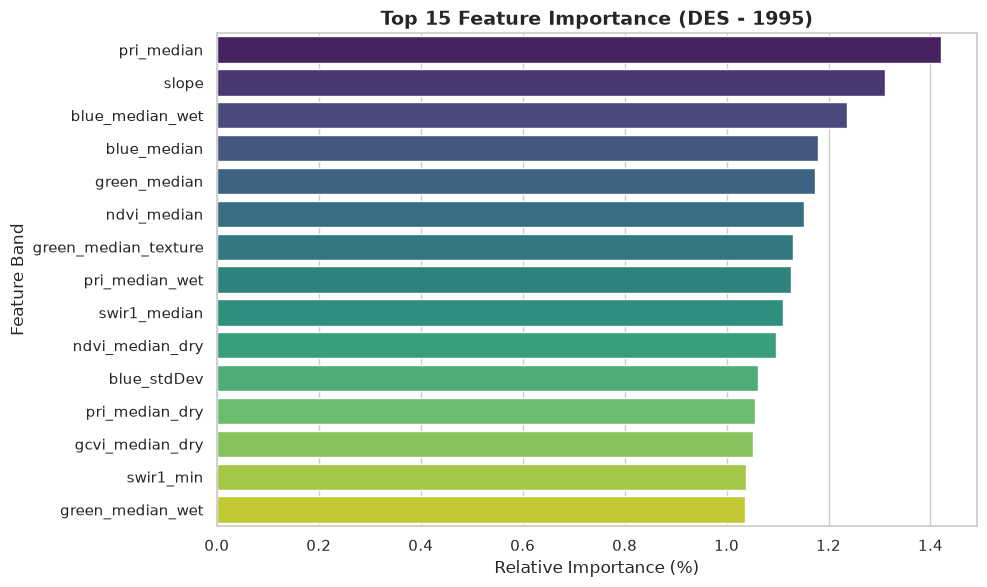

 PROCESSING YEAR: 2005 
Calculating Level 1 class distributions (this may take a moment)...
Executing Configuration: All Features (119 total) using Sample Version: v7...
-> All Features Result | Accuracy: 0.9325 | Weighted F1-Score: 0.9321



/tmp/ipykernel_9851/4041336458.py:52: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='importance', y='band', data=top_features_yr, palette='viridis')


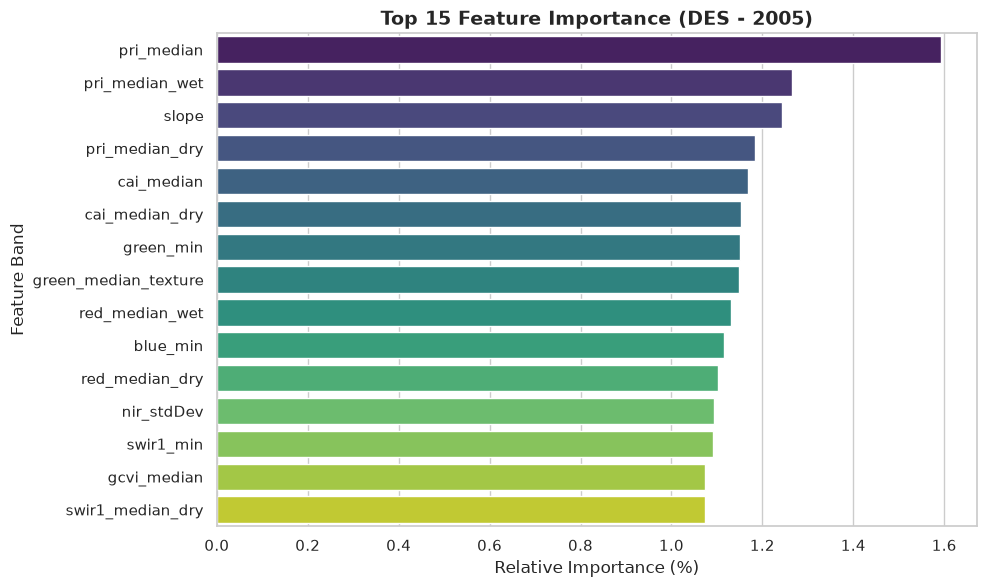

 PROCESSING YEAR: 2015 
Calculating Level 1 class distributions (this may take a moment)...
Executing Configuration: All Features (119 total) using Sample Version: v7...
-> All Features Result | Accuracy: 0.9390 | Weighted F1-Score: 0.9393



/tmp/ipykernel_9851/4041336458.py:52: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='importance', y='band', data=top_features_yr, palette='viridis')


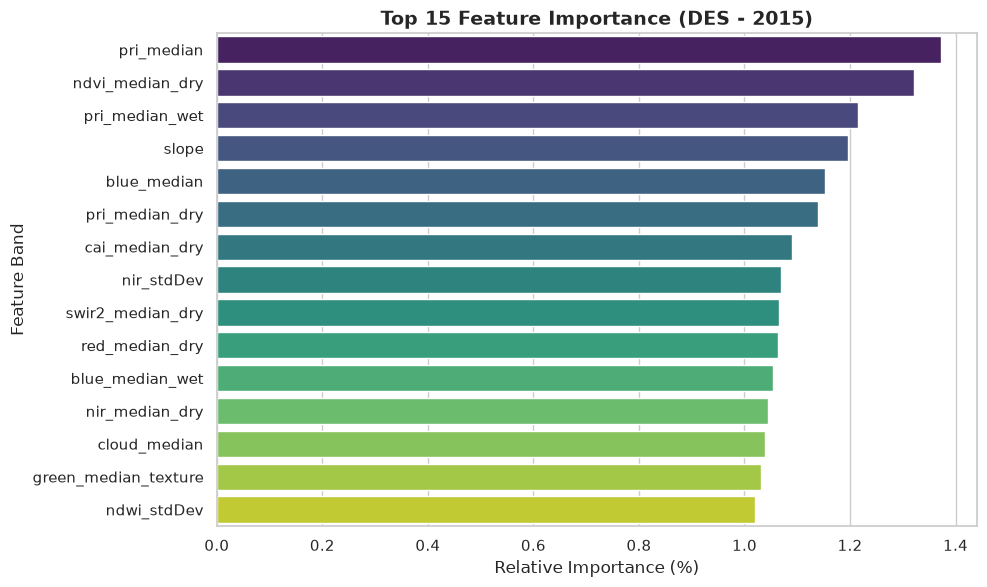

 PROCESSING YEAR: 2024 
Calculating Level 1 class distributions (this may take a moment)...
Executing Configuration: All Features (119 total) using Sample Version: v7...
-> All Features Result | Accuracy: 0.9432 | Weighted F1-Score: 0.9427



/tmp/ipykernel_9851/4041336458.py:52: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='importance', y='band', data=top_features_yr, palette='viridis')


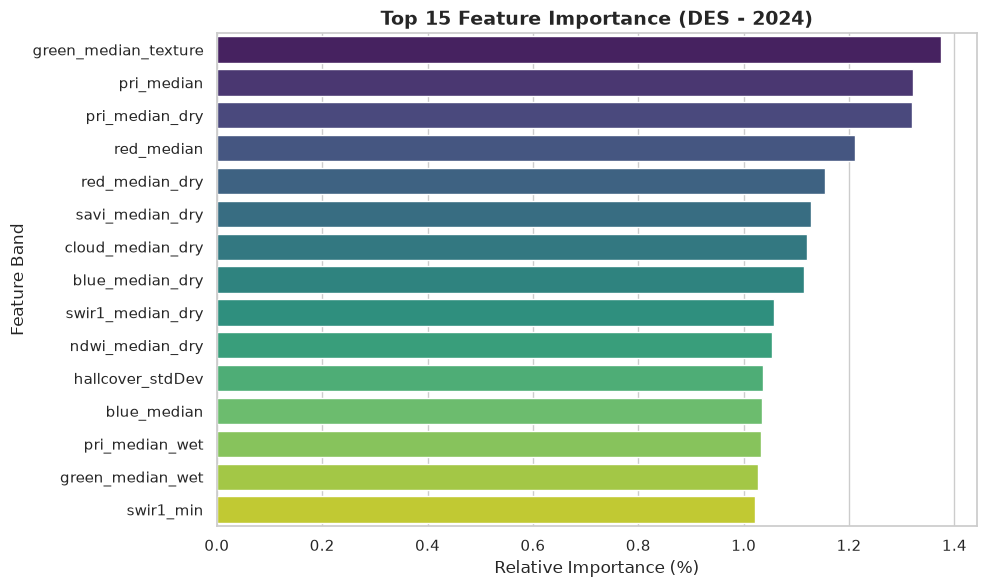


--- Summary Performance Across Years ---
 Year  Accuracy  Weighted F1-Score
 1995  0.909699           0.909098
 2005  0.932495           0.932081
 2015  0.939032           0.939272
 2024  0.943182           0.942658


In [3]:
years = [1995, 2005, 2015, 2024]

# Containers for metrics and feature importance
yearly_metrics = []
yearly_importance_list = []
yearly_predictions = {}
yearly_correlation_matrices = {}

for yr in years:
    print("=" * 70)
    print(f" PROCESSING YEAR: {yr} ")
    print("=" * 70)
    
    # Initialize the module for the current year
    selector = EEFeatureSelectionModule(
        region_id=region_id,
        year=yr,
        sample_version_in=sample_version_in,
        number_of_trees=n_trees
    )
    
    # Load and balance sample distributions
    _ = selector.load_and_balance_data(balance_samples=balance_samples)
    
    # Execute feature selection for 'all_features'
    comp_df, predictions, importance_df, corr_matrix = selector.run_feature_selection(
        case='all_features',
        return_importance=True,
        return_correlation=True
    )
    
    # Collect performance metrics
    acc = comp_df['Accuracy'].iloc[0]
    f1 = comp_df['Weighted F1-Score'].iloc[0]
    yearly_metrics.append({
        'Year': yr,
        'Accuracy': acc,
        'Weighted F1-Score': f1
    })
    
    # Collect predictions
    yearly_predictions[yr] = predictions['All Features']
    yearly_correlation_matrices[yr] = corr_matrix
    
    # Store feature importance
    importance_df['year'] = yr
    yearly_importance_list.append(importance_df)
    
    # Individual Year Plot: Top 15 Feature Importances
    plt.figure(figsize=(10, 6))
    top_features_yr = importance_df.sort_values(by='importance', ascending=False).head(15)
    sns.barplot(x='importance', y='band', data=top_features_yr, palette='viridis')
    plt.title(f'Top 15 Feature Importance ({region_code} - {yr})', fontsize=14, fontweight='bold')
    plt.xlabel('Relative Importance (%)')
    plt.ylabel('Feature Band')
    plt.tight_layout()
    plt.show()

# Convert metrics to DataFrame
metrics_df = pd.DataFrame(yearly_metrics)
master_importance_df = pd.concat(yearly_importance_list, ignore_index=True)

print("\n--- Summary Performance Across Years ---")
print(metrics_df.to_string(index=False))

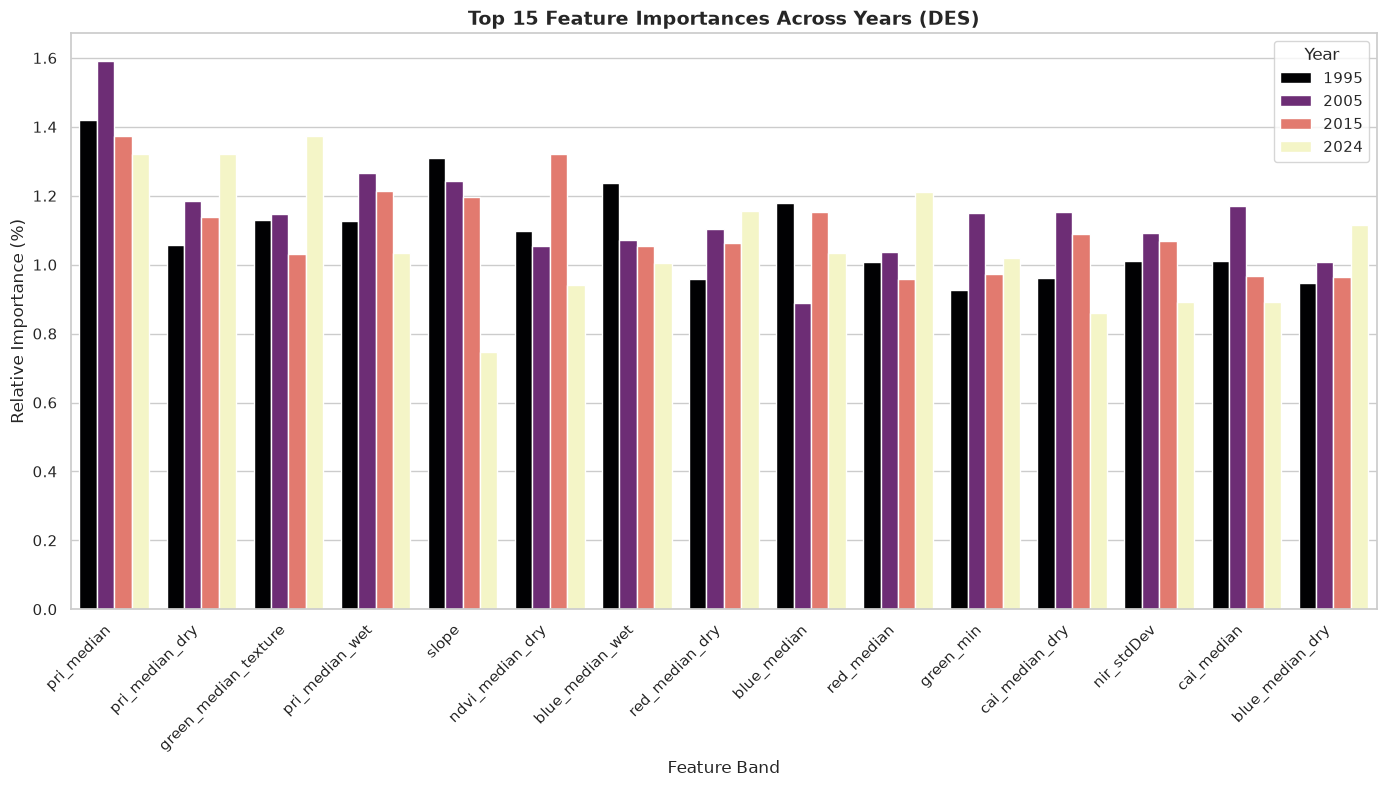

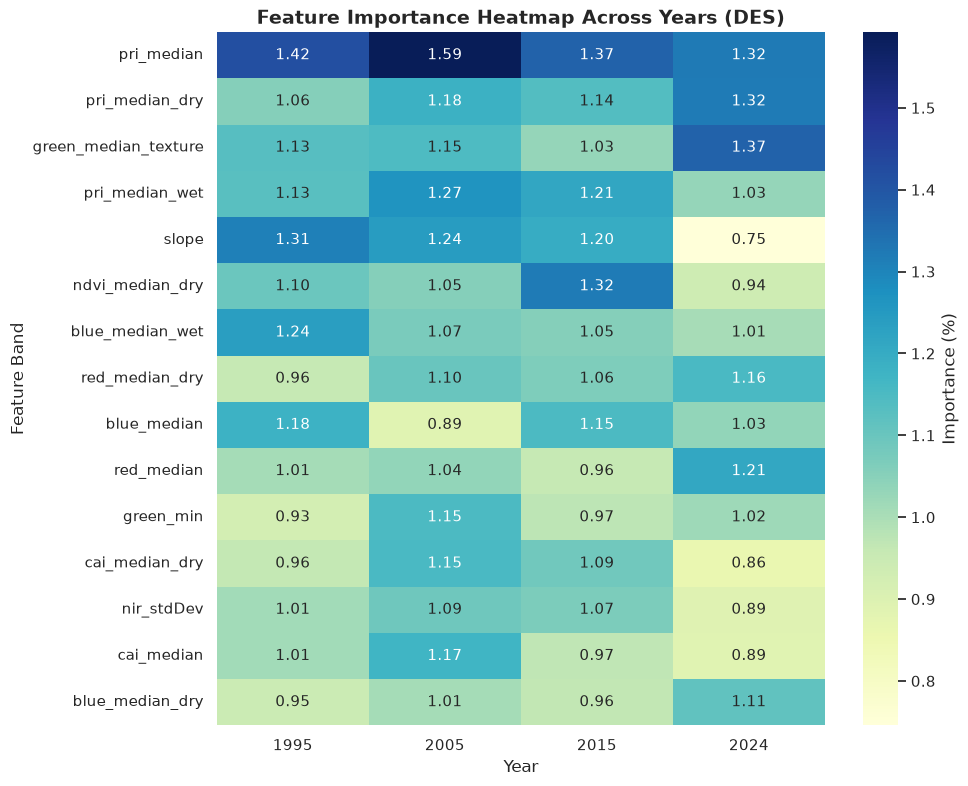

In [4]:
# Identify top 15 features based on average importance across all 4 years
avg_importance = (
    master_importance_df.groupby('band')['importance']
    .mean()
    .sort_values(ascending=False)
    .head(15)
    .index.tolist()
)

top_master_df = master_importance_df[master_importance_df['band'].isin(avg_importance)]

# Grouped Bar Plot: Feature Importance Across Years
plt.figure(figsize=(14, 8))
sns.barplot(
    x='band',
    y='importance',
    hue='year',
    data=top_master_df,
    order=avg_importance,
    palette='magma'
)
plt.title(f'Top 15 Feature Importances Across Years ({region_code})', fontsize=14, fontweight='bold')
plt.xlabel('Feature Band')
plt.ylabel('Relative Importance (%)')
plt.xticks(rotation=45, ha='right')
plt.legend(title='Year')
plt.tight_layout()
plt.show()

# Heatmap: Feature Importance Matrix across Years
pivot_importance = top_master_df.pivot(index='band', columns='year', values='importance').reindex(avg_importance)

plt.figure(figsize=(10, 8))
sns.heatmap(pivot_importance, annot=True, fmt='.2f', cmap='YlGnBu', cbar_kws={'label': 'Importance (%)'})
plt.title(f'Feature Importance Heatmap Across Years ({region_code})', fontsize=14, fontweight='bold')
plt.xlabel('Year')
plt.ylabel('Feature Band')
plt.tight_layout()
plt.show()

In [ ]:
master_importance_df.groupby(['band'])['importance'].mean().reset_index().sort_values(by='importance', ascending=False).head(15)

,band,importance
75,pri_median,1.426732
76,pri_median_dry,1.174952
26,green_median_texture,1.170644
77,pri_median_wet,1.159906
97,slope,1.123912
55,ndvi_median_dry,1.102902
2,blue_median_wet,1.091673
79,red_median_dry,1.070407
0,blue_median,1.063994
78,red_median,1.053474


In [ ]:
# master_importance_df.to_csv('data/feature_importance_multiyear_region3_run.csv')

Train a model to test the performance on these bands

In [5]:
master_importance_df = pd.read_csv('data/feature_importance_multiyear_region3_run.csv')

In [11]:
master_importance_df.groupby(['band'])['importance'].mean().reset_index().sort_values(by='importance', ascending=False).head(15)

,band,importance
75,pri_median,1.426732
76,pri_median_dry,1.174952
26,green_median_texture,1.170644
77,pri_median_wet,1.159906
97,slope,1.123912
55,ndvi_median_dry,1.102902
2,blue_median_wet,1.091673
79,red_median_dry,1.070407
0,blue_median,1.063994
78,red_median,1.053474


In [12]:
master_importance_df.groupby(['band'])['importance'].mean().reset_index().sort_values(by='importance', ascending=False).head(20)['band'].to_list()

['pri_median',
 'pri_median_dry',
 'green_median_texture',
 'pri_median_wet',
 'slope',
 'ndvi_median_dry',
 'blue_median_wet',
 'red_median_dry',
 'blue_median',
 'red_median',
 'green_min',
 'cai_median_dry',
 'nir_stdDev',
 'cai_median',
 'blue_median_dry',
 'swir1_min',
 'red_stdDev',
 'green_median',
 'blue_min',
 'savi_median_dry']

In [13]:
master_importance_df.groupby(['band'])['importance'].median().reset_index().sort_values(by='importance', ascending=False).head(20)['band'].to_list()

['pri_median',
 'slope',
 'pri_median_wet',
 'pri_median_dry',
 'green_median_texture',
 'blue_median',
 'red_median_dry',
 'ndvi_median_dry',
 'blue_median_wet',
 'nir_stdDev',
 'swir1_min',
 'cai_median_dry',
 'red_median',
 'green_median_wet',
 'swir1_median_dry',
 'red_stdDev',
 'ndwi_median_dry',
 'green_min',
 'gcvi_median_dry',
 'cai_median']

In [ ]:
trained_rf_corr, acc_corr, f1_corr, y_true_corr, y_pred_corr = selector.evaluate_model(X_filtered.columns.tolist())